# Ehrenfest chain

A.F.Zarnecki, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

### Chain implementation

In [2]:
# Number of boxes to consider

M = 2

# Number of balls to distribute

N = 100

In [32]:
# Random ball distribution to start with:

dist = np.random.randint(M,size=N)

# Number of balls in each box:

num = [np.sum(dist == k) for k in range(M)]

print("Initial ball distribution: ",num)

Initial ball distribution:  [60, 40]


In [33]:
# Number of steps in chain

Nmc = 1000

# Chain history:

history = np.empty((Nmc+1,M),dtype=np.int32)
history[0] = num

# Run chain algrithm

imc = 0

while imc < Nmc:
    
    iball = np.random.randint(N)    # select a random ball

    ibox = dist[iball]

    inew = (ibox + np.random.randint(1,M) ) % M    # Random new box (M-1 options, exclude the current one)

    dist[iball] = inew
    
    num[ibox] -= 1
    num[inew] += 1
    
    imc+=1
    history[imc] = num

print("Final ball distribution: ",num)

Final ball distribution:  [46, 54]


### Plot the history

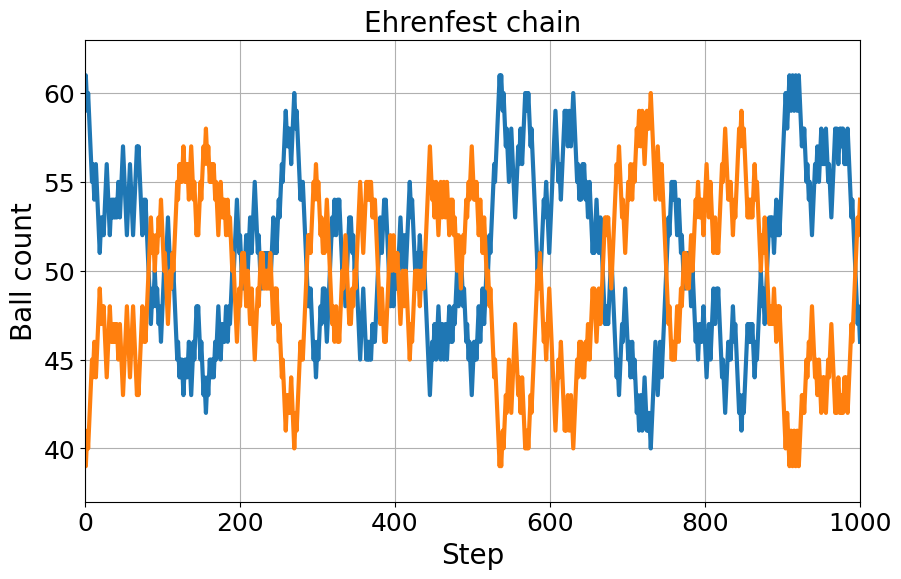

In [34]:
plt.figure(figsize=(10, 6))

for ibox in range(M):
    plt.plot(range(Nmc+1),history[:,ibox],linewidth=3)

plt.title('Ehrenfest chain',size=20)
plt.ylabel('Ball count',size=20)
plt.xlabel('Step',size=20)

plt.xlim([0,Nmc])
plt.ylim([np.min(history)-2,np.max(history)+2])
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

fname = '14_Ehrenfest_'+str(M)+'.png'
plt.savefig(fname)

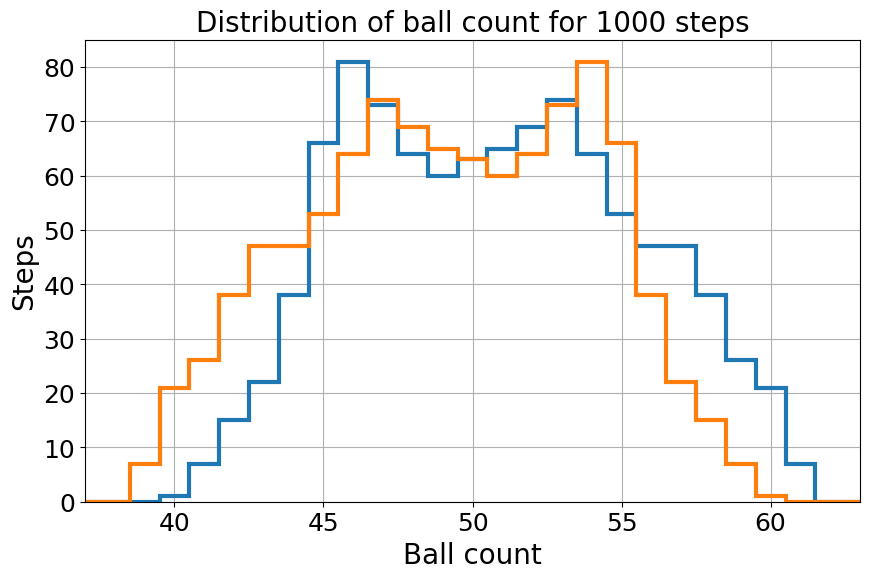

In [35]:
# Histogram range

Nbin = N+1

xmin = -0.5
xmax = N+0.5

plt.figure(figsize=(10, 6))

for ibox in range(M):
    plt.hist(history[:,ibox],range=[xmin,xmax],bins=Nbin,log=False, histtype='step',linewidth=3)

plt.title('Distribution of ball count for '+str(Nmc)+' steps',size=20)
plt.ylabel('Steps',size=20)
plt.xlabel('Ball count',size=20)
plt.xlim([np.min(history)-2,np.max(history)+2])

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both')

fname = '14_Ehrenfest_hist_'+str(M)+'.png'
plt.savefig(fname)